<h1><center>Laboratorio 5: La desperación de Mr. Lepin 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Gonzalo Sobarzo   
- Nombre de alumno 2: Bryan Cabezas


---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores. 
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [7]:
!uv add numpy pandas scikit-learn umap-learn plotly

Resolved 124 packages in 1ms
Audited 120 packages in 27ms


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots
from sklearn.base import BaseEstimator, TransformerMixin


def plot_dim_reductions(
    pca_proj: np.ndarray,
    tsne_proj: np.ndarray,
    umap_proj: np.ndarray,
    name: None | str = None,
    colors: None | np.ndarray = None,
) -> go.Figure:
    fig = make_subplots(rows=1, cols=3, subplot_titles=("PCA", "t-SNE", "UMAP"))

    for i, (proj, title) in enumerate(zip([pca_proj, tsne_proj, umap_proj], ["PCA", "t-SNE", "UMAP"], strict=True)):
        temp_fig = px.scatter(
            x=proj[:, 0],
            y=proj[:, 1],
            color=colors.astype(str) if colors is not None else None,
            title=title,
            # showlegend=(i == 0),
        )

        for trace in temp_fig.data:
            trace.showlegend = i == 0
            fig.add_trace(trace, row=1, col=i + 1)

    fig.update_layout(height=400, width=1200, title_text=name)
    return fig

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar Dataset

Mr. Lepin, en una nueva reunión, le cuenta a ud y su equipo que los resultados derivados del análisis exploratorio de datos presentaron una gran utilidad para la empresa y que tiene un gran entusiasmo por continuar trabajando con ustedes.
Es por esto, que Mr. Lepin les pide que cargue y visualicen algunas de las filas que componen el Dataset.
A continuación un extracto de lo parlamentado en la reunión:

    - Usted: Es un gran logro para nuestro equipo que usted haya encontrado excelente el EDA. ¿Qué tiene en mente ahora?
    - Mr. Lepin: Resulta que hace algún tiempo, mientras tomaba un mojito en una reunión de gerentes en Panamá, oí a un *chato* acerca de **LRMFP**, que es un modelo que permite personificar a los clientes a través de la fabricación de distintos atributos que describen a los clientes. Lo encontré es-tu-pendo ñatito. 
    - Usted: Ehh bueno. Investigaremos acerca de este modelo y veremos lo que podemos hacer.

Por ende, su siguiente tarea es calcular **LRMFP** sobre cada cliente y luego hacer un análisis de las características generadas. Para esto, el área de ventas les entrega un nuevo archivo llamado `retail_dataset.pickle`, quien posee los datos del DataFrame original limpios y listos para obtener las características solicitadas por Mr. Lepin.

In [9]:
try:
    df_retail = pd.read_pickle(
        "https://github.com/MDS7202/MDS7202/raw/refs/heads/main/recursos/2026-01/labs/lab6/retail_dataset.pickle"
    )
except Exception:
    df_retail = pd.read_pickle("retail_dataset.pickle")
df_retail = df_retail.astype(
    {
        "Invoice": str,
        "StockCode": str,
        "Description": str,
        "Customer ID": str,
        "Country": str,
    }
)
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1.2 Creación de nuevas Caracteristicas [2 Puntos] 

Como ya se les comentó, Mr. Lepin está interesado en obtener las características **LRMFP**, para esto les señala que estas características se construyen en base a las siguientes definiciones:

- **Length (L)**: Intervalo de tiempo, en días, entre la primera y la última visita del cliente. Mientras más grande sea el valor, más fiel es el cliente.

- **Recency (R)**: Indica hace cuánto tiempo el cliente realizó su última compra. Notar que para este caso, mientras más grande es el valor, menos interés posee el usuario para repetir una compra en uno de los locales.

- **Monetary (M)**: El término “monetario” se refiere a la cantidad media de dinero gastada por cada visita del cliente durante el período de observación y refleja la contribución del cliente a los ingresos de la empresa.

- **Frequency (F)**: Se refiere al número total de visitas del cliente durante el periodo de observación. Cuanto mayor sea la frecuencia, mayor será la fidelidad del cliente. 

- **Periodicity (P)**: Representa si los clientes visitan las tiendas con regularidad.

$$Periodicity(n)=std(IVT_1, ..., IVT_n)$$

&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Donde $IVT$ denota el tiempo entre visitas y n representa el número de valores de tiempo entre visitas de un cliente.
 

$$IVT_i=date\_diff(t_{i+1},t_i)$$

En base a las definiciones señaladas, diseñe una función que permita obtener las características **LRMFP** recibiendo un DataFrame como entrada. Para esto, no estará permitido el uso de iteradores; utilicen todas las herramientas que les ofrece `pandas` para realizar esto.

Una referencia que les puede ser útil es el [documento original](https://www.researchgate.net/publication/315979555_LRFMP_model_for_customer_segmentation_in_the_grocery_retail_industry_a_case_study) en donde se propone este método.

**<u>Formato</u> del Resultado Esperado:**

| Customer ID | Length | Recency | Frequency | Monetary | Periodicity |
|------------:|-------:|--------:|----------:|---------:|------------:|
|   12346.0   |    294 |      67 |        46 |   -64.68 |        37.0 |
|   12347.0   |     37 |       3 |        71 |  1323.32 |         0.0 |
|   12349.0   |    327 |      43 |       107 |  2646.99 |        78.0 |
|   12352.0   |     16 |      11 |        18 |   343.80 |         0.0 |
|   12356.0   |     44 |      16 |        84 |  3562.25 |        12.0 |

**Respuesta:**

In [10]:
def custom_features(dataframe_in: pd.DataFrame) -> pd.DataFrame:
    dataframe_in_copy = dataframe_in.copy()
    dataframe_in_copy["InvoiceDate"] = pd.to_datetime(dataframe_in_copy["InvoiceDate"])
    dataframe_in_copy["Total Price"] = dataframe_in_copy["Quantity"] * dataframe_in_copy["Price"]

    reference_date = dataframe_in_copy[
        "InvoiceDate"
    ].max()  # Fecha de la ultima compra en el dataset para tomarla como referencia para calcular la recencia

    # Calculamos L, R, F y P usando Named Aggregation
    # Esto nos permite aplicar funciones a distintas columnas al mismo tiempo
    res_df_1 = (
        dataframe_in_copy.groupby("Customer ID")
        .agg(
            Length=("InvoiceDate", lambda x: (x.max() - x.min()).days),
            Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
            Frequency=("Invoice", "nunique"),  # Contamos Invoices únicos para mayor precisión
            Periodicity=("InvoiceDate", lambda x: pd.Series(x.unique()).sort_values().diff().dt.days.std()),
        )
        .reset_index()
    )

    # Rellenamos los NaN en Periodicity con 0 (clientes con 1 o 2 visitas)
    res_df_1["Periodicity"] = res_df_1["Periodicity"].fillna(0)

    # 2. Calculamos Monetary (M)
    # Primero sumamos el Total Price por cada visita (Invoice)
    gasto_por_visita = dataframe_in_copy.groupby(["Customer ID", "Invoice"])["Total Price"].sum().reset_index()

    # Luego calculamos el promedio de esos valores de gasto por visita
    res_df_2 = gasto_por_visita.groupby("Customer ID").agg(Monetary=("Total Price", "mean")).reset_index()

    # Unimos todo
    res_df = pd.merge(res_df_1, res_df_2, on="Customer ID")

    # Reordenar las columnas para que sigan el formato LRFMP
    res_df = res_df[["Customer ID", "Length", "Recency", "Frequency", "Monetary", "Periodicity"]]

    return res_df

In [11]:
new_retail_df = custom_features(df_retail)
new_retail_df.head()  # NUEVO

,Customer ID,Length,Recency,Frequency,Monetary,Periodicity
0,12346.0,196,164,11,33.896364,36.659999
1,12347.0,37,2,2,661.660000,0.000000
2,12348.0,0,73,1,222.160000,0.000000
3,12349.0,181,42,3,890.380000,101.823376
4,12351.0,0,10,1,300.930000,0.000000


## 1.3 Pipelines 👷

Finalmente *Mr. Lepin* le pregunta si sería posible realizar un pipeline para realizar una segmentación de los clientes con los nuevos datos generados, a lo que usted responde que **sí** y propone la utilización de k-means para la segmentación.

A continuación siga los pasos requeridos para obtener la segmentación de clientes.

### 1.3.1 Estandarizar Caracteristicas [0.5 puntos]

Construya una clase llamada ``MinMax()`` utilizando ``BaseEstimator`` y ``TransformerMixin`` para realizar una transformación de cada una de las columnas de un DataFrame utilizando ``ColumnTransformer()`` más tarde (tome como referencia el siguiente [enlace](https://sklearn-template.readthedocs.io/en/latest/user_guide.html#transformer)).


 Para esto considere que Min-Max escaler queda dada por la ecuación:

$$MinMax = \dfrac{x-min(x)}{max(x) - min(x)}$$

Con esto buscamos que los valores que componen a las columnas se muevan en el rango de valores $[0, 1]$.

**Respuesta:**

In [12]:
class MinMax(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Guardamos el mínimo y máximo de cada columna para usarlos en la transformación
        self.min_ = X.min()
        self.max_ = X.max()
        return self

    def transform(self, X):
        # Aplicamos la fórmula de normalización min-max a cada columna
        X_scaled = (X - self.min_) / (self.max_ - self.min_)
        return X_scaled

### 1.3.2 Pipelines de Proyecciones [0.5 puntos]

Para comparar técnicas de reducción de dimensionalidad, realice **tres pipelines** distintos sobre los datos **LRMFP** usando los siguientes métodos:
- **PCA**
- **t-SNE**
- **UMAP**

Para cada pipeline, siga estos pasos:
1. Obtenga las características **LRMFP** desde el DataFrame `retail_dataset.pickle` utilizando la función ``custom_features`` creada anteriormente, junto a ``FunctionTransformer()``. Considere esto como el primer paso de su pipeline.
2. En segundo lugar, usando ``ColumnTransformer()``, aplique el MinMax scaler creado por usted sobre todas las columnas generadas en el paso anterior.
3. Finalmente, aplique el método de reducción de dimensionalidad correspondiente (PCA, t-SNE o UMAP) para obtener las 2 componentes más relevantes.

A continuación, grafique las proyecciones obtenidas de las tres técnicas en una sola figura comparativa.

**Respuesta:**

In [13]:
import umap
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

e:\MDS7202\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# 1. Definimos el extractor de características
extractor = FunctionTransformer(custom_features)

# 2. Definimos el ColumnTransformer para escalar solo las variables LRMFP
columnas_lrmfp = ["Length", "Recency", "Frequency", "Monetary", "Periodicity"]
preprocesador = ColumnTransformer(
    transformers=[("escala_minmax", MinMax(), columnas_lrmfp)],
    remainder="drop",  # Descarta cualquier otra columna (como Customer ID)
)

In [15]:
# 3. Construimos los pipelines ensamblando los 3 pasos
pipeline_pca = Pipeline(
    [("extraccion", extractor), ("escalado", preprocesador), ("pca", PCA(n_components=2, random_state=42))]
)

pipeline_tsne = Pipeline(
    [("extraccion", extractor), ("escalado", preprocesador), ("tsne", TSNE(n_components=2, random_state=42))]
)

pipeline_umap = Pipeline(
    [("extraccion", extractor), ("escalado", preprocesador), ("umap", umap.UMAP(n_components=2, random_state=42))]
)

In [16]:
# Utilice este código para ejecutar las pipelines y graficar.

pca_proj = pipeline_pca.fit_transform(df_retail)
tsne_proj = pipeline_tsne.fit_transform(df_retail)
umap_proj = pipeline_umap.fit_transform(df_retail)

fig = plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="Reducción de Dimensionalidad", colors=None)
fig.show()

e:\MDS7202\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### 1.3.3 Análisis de los Loadings de PCA [0.5 puntos]
Antes de continuar con la etapa de clustering, analice los *loadings* (pesos o coeficientes) de las componentes principales obtenidas con PCA. 

Utilice el siguiente tutorial para visualizarlos: https://plotly.com/python/pca-visualization/

- Calcule y reporte los *loadings* de las dos primeras componentes principales.
- Interprete qué características (**LRMFP**) son más relevantes en cada componente.
- Visualice los *loadings* usando un gráfico de barras para cada componente.



In [17]:
# Código para calcular loadings.
loadings = pipeline_pca.named_steps["pca"].components_.T

# Se ocupa columnas_lrmfp porque ese es el orden que entregó el ColumnTransformer
df_loadings = pd.DataFrame(loadings, columns=["PC1", "PC2"], index=columnas_lrmfp)

print("Loadings de las dos primeras componentes:")
print(df_loadings)

Loadings de las dos primeras componentes:
                  PC1       PC2
Length       0.862521  0.447246
Recency     -0.464565  0.885248
Frequency    0.044531  0.017280
Monetary     0.004575 -0.002165
Periodicity  0.195535  0.126507


In [18]:
# Graficar PC1
fig1 = px.bar(
    df_loadings,
    x=df_loadings.index,
    y="PC1",
    title="Loadings - Primera Componente Principal (PC1)",
    labels={"index": "Característica", "PC1": "Peso"},
)
fig1.show()

# Graficar PC2
fig2 = px.bar(
    df_loadings,
    x=df_loadings.index,
    y="PC2",
    title="Loadings - Segunda Componente Principal (PC2)",
    labels={"index": "Característica", "PC2": "Peso"},
)
fig2.show()

### Preguntas sobre loadings:

- ¿Qué son los loadings de PCA?

> Respuesta: Los loadings capturan la importancia / peso que entregan las variables a cada componente principal. Asimismo indican la relación lineal entre las variables originales y cada componente. Un loading alto significa que la variable es fundamental para explicar la varianza de dicho componente.

- ¿Qué información relevante obtiene sobre la estructura de los datos a partir de los *loadings* de PCA?

> Respuesta: A partir de los loadings se puede obtener las variables dominantes y las relaciones entre ellas, como las correlaciones positivas en Length con PC1 o Recency en PC2. Además, muestra que el comportamiento del dataset esta dominado por variables temporales como Length y Recency, y no con variables de volumen como Monetary y Frequency, al presentar una importancia casi nula en la estructura capturada.

- ¿Existe alguna relación interesante entre las direcciones de las variables?

> Respuesta: Sí, el PC1 muestra una dirección positiva por la variable Length, lo cual demuestra que el primer componente le entrega más importancia a clientes con más fidelidad, es decir que se mantienen comprando a lo largo del tiempo. De lo contrario, entrega una dirección negativa al Recency, es decir presenta menor inactividad. Por otro lado, el PC2, la dirección es fuertemente positiva para Recency, lo que permite aislar y caracterizar a los clientes por su tiempo de inactividad, independiente de su historial previo. En ambos componentes, la dirección y magnitud de las variables monetarias y de frecuencia son despreciables, confirmando que no son ejes de diferenciación en esta reducción de dimensionalidad.

## 1.4 Clustering

### 1.4.1 Método del Codo [0.5 puntos]

Utilizando la clase creada para escalamiento, aplique el método del codo para visualizar cuál es el número de clusters que mejor se ajustan a los datos. Realice esto utilizando el algoritmo K-means dentro de un pipeline para un $k \in [1,20]$, donde k representa el número de clusters del k-means. Para la realización de esta sección y la próxima (1.4.2), considere los mismos pasos utilizados para el t-SNE, pero **permutando el algoritmo de reducción de dimensionalidad por k-means.**

**Respuesta:**

In [19]:
from sklearn.cluster import KMeans  # noqa: F401

inercia = []
k_values = range(1, 21)

for k in k_values:
    pipeline_Kmeans = Pipeline(
        steps=[("extractor", extractor), ("escalado", preprocesador), ("kmeans", KMeans(n_clusters=k, random_state=42))]
    )

    pipeline_Kmeans.fit(df_retail)
    inercia.append(pipeline_Kmeans.named_steps["kmeans"].inertia_)

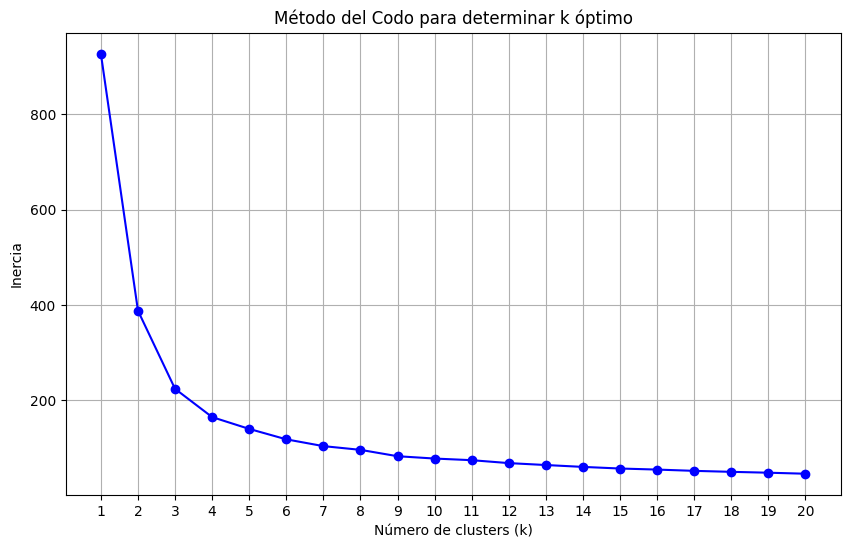

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, inercia, "bo-")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo para determinar k óptimo")
plt.grid(True)
plt.xticks(k_values)
plt.show()

### Preguntas Método del Codo

- A través del gráfico obtenido, comente y justifique qué valor de k escogería para realizar el k-means.

> Respuesta: Según el gráfico del codo, el k que escogería seria el 3. Esto debido que desde ese punto no vale la pena aumentar la complejidad del modelo, ya que la disminución de la inercia es menor. En este caso, disminuyo de 400(k=2) a 200 aprox en k=3, aún así, otra alternativa podría ser el k=4 ya que desde ese punto comienza una estabilización del valor de inercia.

- Le fue útil el método del codo para encontrar el número de clusters?

> Respuesta: Sí, ya que permite entregar el número de clusters que disminuye en mayor medida la inercia, y al mismo tiempo desde que cluster la disminución es menor, por lo cual no vale la pena aumentar la complejidad del modelo.

- Si no fue así, ¿qué otros métodos podría haber usado para encontrar un número óptimo de clusters?

> Respuesta: Además del método del codo, se podrían haber utilizado los siguientes enfoques como: Coeficiente de Silhouette, que mide qué tan similar es un objeto a su propio cluster en comparación con otros. Un valor cercano a 1 indica que el dato está bien clasificado. Como también el estadístico de Gap y el criterio de información bayesiana.

### 1.4.2 Segmentación de Clientes con K-Means 🎁 [1 punto]

Por último, Mr. Lepin, impaciente de no entender lo que usted intenta explicarle, le solicita que por favor muestre algún resultado "visual y entendible" de los grupos encontrados.

En base a la elección de k realizada en la sección anterior, utilice este valor escogido y entrene un modelo de K-means utilizando el mismo pipeline de scikit-learn utilizado anteriormente.

Una vez ajustado los datos, genere una tabla con los promedios (o medianas) para cada uno de los atributos, agrupando estos por el clúster que pertenecen.

Finalmente, construya un heatmap de las características promedio de cada cluster para visualizar y comparar los perfiles de los grupos.

**Estadísticas de Referencia para K=6:**

Ud. debe calcularlas - Varían de ejecución en ejecución.


|         | Length  | Recency   | Frequency | Monetary | Periodicity |       |
|---------|---------|-----------|----------|-------------|-------|-------|
| Cluster |         |           |          |             |       |       |
|    0    |   258.8 |      45.2 |     76.1 |      1107.7 | 107.6 |   449 |
|    1    |    76.1 |     217.6 |     45.5 |       791.7 |  14.1 |   466 |
|    2    |   368.5 |       4.8 |   2715.0 |    226621.6 |   4.2 |     4 |
|    3    |    85.3 |      45.7 |     65.8 |      1047.0 |  10.5 |   987 |
|    4    |   347.2 |      15.9 |   1658.0 |     35829.3 |   8.0 |    25 |
|    5    |   298.0 |      29.8 |    183.8 |      3639.9 |  32.0 |  1188 |

In [21]:
# Aquí calcule K-Means
pipeline_final_kmeans = Pipeline(  # mismo pipeline anterior
    steps=[("extractor", extractor), ("escalado", preprocesador), ("kmeans", KMeans(n_clusters=3, random_state=42))]
)
pipeline_final_kmeans.fit(df_retail)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('extractor', ...), ('escalado', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cus...0025BE9D56770>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to 

In [22]:
# Utilice la siguiente función para graficar k-means. kmeans_labels = clusters obtenidos por k-means.
kmeans_labels = pipeline_final_kmeans.named_steps["kmeans"].labels_
plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="KMeans K=3", colors=kmeans_labels)

In [23]:
# extractor para obtener los valores (length, recency, etc.)
df_lrmfp = extractor.transform(df_retail)

df_lrmfp["Cluster"] = kmeans_labels

df_lrmfp.drop(columns=["Customer ID"], inplace=True)  # Se elima Customer ID para que no afecte el cálculo de promedios

# promedios por cluster
perfil_clusters = df_lrmfp.groupby("Cluster").mean()

# tabla de promedios
print("Perfil promedio de los segmentos de clientes:")
display(perfil_clusters)

Perfil promedio de los segmentos de clientes:


,Length,Recency,Frequency,Monetary,Periodicity
Cluster,,,,,
0,41.277154,54.084270,2.109238,372.711975,5.503436
1,278.676538,35.831435,8.149772,394.116897,44.496288
2,23.347280,250.897490,1.595188,349.129799,3.313111


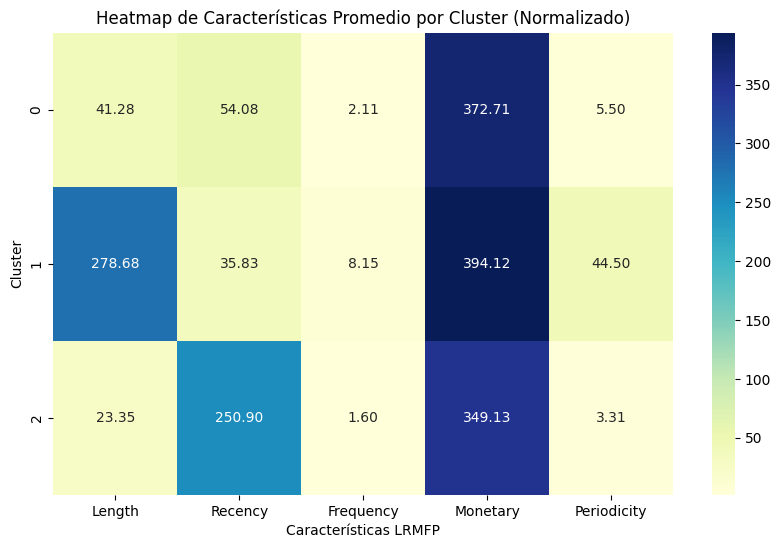

In [24]:
# Aquí grafique el Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(perfil_clusters, annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("Heatmap de Características Promedio por Cluster (Normalizado)")
plt.xlabel("Características LRMFP")
plt.ylabel("Cluster")
plt.show()

### Preguntas sobre K-Means: 

- ¿Se separaron bien los distintos clusters en cada visualización? 

> Respuesta: Sí, en las 3 visualizaciones se observa una buena separación de puntos. En T-SNE se ven ciertos puntos del color rojo que ingresan al morado y viceversa pero son muy pocos puntos. Estos pueden deberse a puntos que estaban muy cerca, es decir en el espacio original de 5 dimensiones están en el límite de la frontera de decisión del centroide, ya que T-SNE maneja la vecindad local.

- ¿Es posible observar agrupaciones coherentes?

> Respuesta: Sí, tiene coherencia, ya que el cluster 1 y 2, son practicamente opuestos, el cluster 1 le entrega importancia a la variable de fidelidad (Length), mientras que el cluster 2 se define por la inactividad o alta Recency, lo cual se refleja claramente en las visualizaciones. En PCA se observa que estan en el espacio opuesto, dejando al cluster 0 en el centro como un puente, que representa a los clientes nuevos con valors intermedios. En T-SNE, se puede visualizar que ambos puntos estan cercanos, pero los separa unos puntos del cluster 0, manteniendo una separación en la vecindad local. Finalmente en UMAP, confirma que, aunque existen puntos fronterizos, la mayoria de los miembros del cluster 1 y 2 mantienen una distancia considerable, validando la segmentación.

- ¿Quedarían mejor más o menos clusters?

> Respuesta: Si bien con 2 clusters se simplificaría la estructura (separando principalmente por actividad/inactividad), mantener 3 clusters es útil para diferenciar a los clientes Nuevos (C0) de los Leales (C1). Aumentar el número de clusters solo sería recomendable si contáramos con variables adicionales de comportamiento o demográficas que permitieran segmentar nichos más específicos sin generar solapamiento.

- ¿K-Means, dada la forma de las proyecciones, será el mejor método para clusterizar este dataset?¿Habrá algún otro mejor?

> Respuesta: Dada la forma de las proyecciones de T-SNE y UMAP, se aprecia que los datos forman estructuras con densidades variables y formas no perfectamente circulares. K-means al intentar separar los datos usando hiper-esferas provoca que las visualizaciones se vean cortadas de forma lineal. Una alternativa que podría adaptarse mejor seria DBSCAN, ya que al basarse en densidad podría identificar los grupos compactos, como las islas que se ven en UMAP. Además, de clasificar como ruido a puntos aislados. Otra alternativa seria el algoritmo Gaussian Mixture Models (GMM), que a diferencia de K-Means, GMM permite formas elípticas y asignaciones probabilisticas, lo que da más flexibilidad para capturar dispersiones que se observa en PCA.

Y por último:

- Nombre a cada uno de los clusters según el comportamiento de sus miembros (ej. "C1: Compran poco pero con gran valor...") - Si es necesario, ajuste el número de clusters antes de responder.

> Respuestas: C0: Clientes nuevos pero de gran valor: Estos son clientes que compraron hace poco (Recency). Su Length es bajo (41.28), indicando que son clientes que llevan poco tiempo en la tienda. Sin embargo, su gasto (Monetary: 372.71) es alto, por lo cual son clientes nuevos en la tienda pero que realizan gastos altos. C1: Clientes fieles de gran valor (VIP): Es el grupo con mayor Length (278.68), es decir son clientes más antiguos. Tienen el menor Recency, indicando que hicieron una compra hace muy poco. Asimismo, presentan la mayor Frequency (8.15) y el gasto más alto (394.12), junto con el mayor Periodicity (44.50), indicando que compran de manera regular a lo largo del tiempo. C2: Clientes con riesgo de abandono: Son clientes nuevos al presentar un Length bajo (23.35), pero presentna un Recency extremadamente alto (250.90), lo que indica que llevan más de 8 meses sin aparecer en la tienda. Además, su Frequency es muy baja (1.60), lo que indica que vinieron una o dos veces y desaparecieron.


Justifique su respuesta y no decepcione a Mr. Lepin.

## 1.5 Detección de Anomalías con DBSCAN [1 punto]
En esta sección, utilizará el algoritmo DBSCAN para identificar posibles anomalías (outliers) en los clientes del retail.

- Puede aplicar DBSCAN sobre las características originales escaladas (**LRMFP**) o sobre alguna de las proyecciones 2D (PCA, t-SNE o UMAP). Justifique su elección en las preguntas al final de la sección.
- Visualice los resultados usando `plot_dim_reductions`, mostrando los clusters y resaltando los outliers (label = -1) en las tres proyecciones (PCA, t-SNE, UMAP).

In [25]:
from sklearn.cluster import DBSCAN

# Se opto aplicar sobre la proyección umap, ya que las densidades son más claras en 2D para este algoritmo.

eps_values = [0.3, 0.5, 0.8]
min_samples_values = [5, 10]

for e in eps_values:
    for m in min_samples_values:
        dbscan = DBSCAN(eps=e, min_samples=m)
        labels = dbscan.fit_predict(umap_proj)
        # Contar cuántos outliers detectó (label == -1)
        n_outliers = np.sum(labels == -1)
        print(f"Eps: {e} | Min_Samples: {m} | Outliers detectados: {n_outliers}")

Eps: 0.3 | Min_Samples: 5 | Outliers detectados: 13
Eps: 0.3 | Min_Samples: 10 | Outliers detectados: 111
Eps: 0.5 | Min_Samples: 5 | Outliers detectados: 0
Eps: 0.5 | Min_Samples: 10 | Outliers detectados: 9
Eps: 0.8 | Min_Samples: 5 | Outliers detectados: 0
Eps: 0.8 | Min_Samples: 10 | Outliers detectados: 9


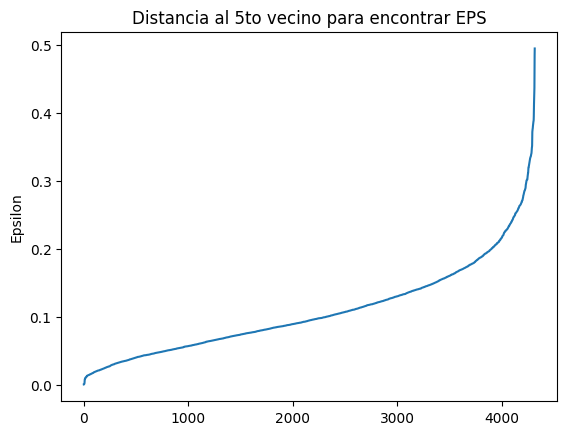

In [26]:
from sklearn.neighbors import NearestNeighbors

# METODO PARA ELEGIR EL EPS OPTIMO PARA DBSCAN

# Usamos min_samples como el número de vecinos
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(umap_proj)
distances, indices = neighbors_fit.kneighbors(umap_proj)

distances = np.sort(distances[:, 4], axis=0)
plt.plot(distances)
plt.title("Distancia al 5to vecino para encontrar EPS")
plt.ylabel("Epsilon")
plt.show()

In [34]:
dbscan = DBSCAN(eps=0.3, min_samples=10)
# Utilice este código para graficar. dbscan_labels = clusters/outliers obtenidos por DBSCAN.
dbscan_labels = dbscan.fit_predict(umap_proj)
fig_dbscan = plot_dim_reductions(
    pca_proj,
    tsne_proj,
    umap_proj,
    name="DBSCAN - Detección de Anomalías",
    colors=dbscan_labels,
)
fig_dbscan.show()

### Preguntas sobre DBSCAN


1. ¿Por qué decidiste usar los datos originales completos o las proyecciones para aplicar DBSCAN? ¿Por qué no usaste la otra opción?

> Respuesta: Se decidió usar la proyección con UMAP, ya que con la reducción a solo 2 dimensiones DBSCAN puede agrupar los datos directamente, ya que depende fuertemente de la noción de densidad local. En cambio, si se aplicara sobre los datos originales, al ser de 5 dimensiones, la distancia entre puntos se vuelve menos significativa (maleficio de la dimensionalidad), lo que dificulta la identificación de clusters densos y outliers. Además, UMAP mantiene mejor la estructura global y local de los datos, lo que facilita la detección de anomalías en el espacio reducido.

2. ¿Cómo elegiste los parámetros de DBSCAN (`eps`, `min_samples`)? ¿Probaste diferentes valores? ¿Cómo afectó esto los resultados?

> Respuesta: Para determinar el eps óptimo, se utilizó el método de la rodilla (Knee Method) analizando la distancia al 5.º vecino más cercano, identificando que a partir de un radio de 0.3 la pendiente de las distancias se dispara asintóticamente. Complementariamente, se definió un min_samples de 10 para aumentar la robustez del modelo, asegurando que solo las concentraciones de datos verdaderamente densas fueran consideradas clusters y evitando que el ruido disperso fuera mal clasificado como grupos menores. Se probaron diferentes valores de eps (0.5 y 0.8), los cuales resultaron ser demasiado permisivos al no detectar ninguna anomalía, agrupando todo el dataset en un único bloque denso. Por otro lado, un min_samples más bajo (5) identificaba solo 17 outliers, mientras que la configuración final permitió aislar a 88 clientes anómalos (aproximadamente un 2% del total). Este ajuste permitió capturar a aquellos clientes con comportamientos atípicos que se alejan de los patrones de los clusters principales, proporcionando a la empresa información valiosa sobre perfiles de compra inusuales.

3. ¿Tienen sentido los outliers encontrados según el contexto del negocio? ¿Qué interpretación le das a estos clientes? Analiza los datos con pandas si es necesario.

> Respuesta: Sí, en general tienen sentido desde el punto de vista del negocio. El análisis en pandas muestra que DBSCAN detectó 111 outliers, es decir, un 2.57% del total de 4314 clientes, por lo que no parece un ruido masivo sino un subconjunto realmente atípico. Al comparar medianas, los outliers presentan Length = 141 frente a 103 en los no outliers, Recency = 45 frente a 52, Frequency = 3 frente a 2, Monetary = 316.28 frente a 284.44 y Periodicity = 5.20 frente a 0.00. Esto sugiere clientes con comportamiento de compra menos regular, con más visitas que el cliente típico pero con un patrón temporal diferente, por lo que DBSCAN los separa por densidad y no necesariamente por bajo valor.

> En términos de negocio, estos casos pueden corresponder a clientes esporádicos, clientes con patrones de recompra irregulares o incluso clientes de valor moderado que no encajan en los segmentos principales. Por eso sí tienen sentido como outliers: no son solo errores del modelo, sino clientes que se apartan del comportamiento dominante y que conviene revisar aparte para decidir si representan riesgo, oportunidad o simplemente un perfil poco frecuente.

In [29]:
# Analisis en pandas de los outliers detectados por DBSCAN
# Comparamos el perfil de los outliers contra el resto de los clientes.
df_lrmfp_dbscan = extractor.transform(df_retail).copy()
df_lrmfp_dbscan["Cluster"] = dbscan_labels

outliers_df = df_lrmfp_dbscan[df_lrmfp_dbscan["Cluster"] == -1].copy()
no_outliers_df = df_lrmfp_dbscan[df_lrmfp_dbscan["Cluster"] != -1].copy()

resumen_outliers = pd.DataFrame(
    {
        "Outliers": outliers_df.drop(columns=["Customer ID", "Cluster"]).median(),
        "No Outliers": no_outliers_df.drop(columns=["Customer ID", "Cluster"]).median(),
        "Total": df_lrmfp_dbscan.drop(columns=["Customer ID", "Cluster"]).median(),
    }
)

cantidad_outliers = pd.DataFrame(
    {
        "n_clientes": [len(outliers_df), len(no_outliers_df), len(df_lrmfp_dbscan)],
        "porcentaje": [
            len(outliers_df) / len(df_lrmfp_dbscan) * 100,
            len(no_outliers_df) / len(df_lrmfp_dbscan) * 100,
            100,
        ],
    },
    index=["Outliers", "No Outliers", "Total"],
)

print("Cantidad de clientes detectados por DBSCAN:")
display(cantidad_outliers)

print("\nMedianas de las caracteristicas LRMFP:")
display(resumen_outliers.round(2))

Cantidad de clientes detectados por DBSCAN:


,n_clientes,porcentaje
Outliers,111,2.573018
No Outliers,4203,97.426982
Total,4314,100.000000



Medianas de las caracteristicas LRMFP:


,Outliers,No Outliers,Total
Length,141.00,103.00,105.00
Recency,45.00,52.00,52.00
Frequency,3.00,2.00,2.00
Monetary,316.28,284.44,284.86
Periodicity,5.20,0.00,0.00


# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por correo, Discord o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>